In [1]:
import pickle
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
with open("/tank/home/zachkaras/fmri_model_data/intermediate_results/all_results_regressor+features.pkl", 'rb') as f:
    records = pickle.load(f)
print(records.columns)

Index(['participant', 'task', 'model', 'ndelays', 'look_ahead', 'layer',
       'top_voxel_vals', 'participant_means', 'top_parcels'],
      dtype='str')


In [3]:
demo_data = pd.read_csv("/tank/home/zachkaras/fmri_model/master-survey-data.csv")
demo_data['years_experience'] = demo_data['semesters_experience'] / 2
demo_data['code_more_structured'] = demo_data['Code_more_structured'].map({'X': 0, 'Y': 1})
demo_data = demo_data.set_index('id')
# print(demo_data[['age', 'GPA', 'years_experience']].describe())
# print("\nCode_more_structured value counts (X=0, Y=1):")
# print(demo_data['code_more_structured'].value_counts(dropna=False))

In [4]:
with open('typing_counts.pkl', 'rb') as f:
    typing_counts = pickle.load(f)

In [5]:

# Add keystroke-based variables to demo_data (separately for code and prose)
for pid_str, tasks in typing_counts.items():
    pid = int(pid_str)
    if pid not in demo_data.index:
        continue
    for task in ['code', 'prose']:
        try:
            total_keys = tasks[task]['total_keys_pressed']
        except:
            print(f"No {task} task for {pid}.")
            continue
        total_backspaces = tasks[task]['total_backspaces']
        demo_data.loc[pid, f'{task}_total_keystrokes'] = total_keys
        demo_data.loc[pid, f'{task}_editing_rate'] = total_backspaces / total_keys if total_keys > 0 else float('nan')

No prose task for 101.
No code task for 130.


In [6]:
best_models = [
            # 'code-deepseek_6b-ndelays_4-look_ahead_by_10',
               'code-deepseek_6b-ndelays_10-look_ahead_by_0',
               'prose-deepseek_6b-ndelays_10-look_ahead_by_0',
            #    'code-codegemma_7b-ndelays_4-look_ahead_by_10',
            #    'code-codegemma_7b-ndelays_16-look_ahead_by_0',
            #    'prose-codegemma_7b-ndelays_10-look_ahead_by_5',
            #    'prose-deepseek_6b-ndelays_20-look_ahead_by_10'
                # 'prose-deepseek_6b-ndelays_4-look_ahead_by_10',
                # 'prose-starcoder2_7b-ndelays_16-look_ahead_by_3'
            ]

model_labels = {
    'code-deepseek_6b-ndelays_10-look_ahead_by_0' : 'Code - DeepSeek 6B',
    'prose-deepseek_6b-ndelays_10-look_ahead_by_0': 'Prose - DeepSeek 6B',
}

variables = {
    'GPA': 'GPA',
    'Age': 'age',
    'Years of Experience': 'years_experience',
    'Code Editing': 'code_editing_rate',
    'Prose Editing': 'prose_editing_rate',
    'Code Total Keystrokes': 'code_total_keystrokes',
    'Prose Total Keystrokes': 'prose_total_keystrokes',
    'Code Correct' : 'code_correct'
}

In [7]:
participant_means = {}

for m in best_models:
    
    participant_means[m] ={}
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]

    mask = ((records['task'] == task) & 
            (records['model'] == model) & 
            (records['ndelays'] == delays) &
            (records['look_ahead'] == look_ahead))
    
    for p, df in records[mask].groupby(['participant']):
        p = p[0]
        layer_mean = df['top_voxel_vals'].explode().mean()
        participant_means[m][p] = layer_mean

In [8]:
import matplotlib.cm as cm
palette = [cm.rainbow(x) for x in np.linspace(0, 1, len(list(variables.keys())))] 
rng = np.random.default_rng(seed=474)                                                                                                                                                                      
rng.shuffle(palette)


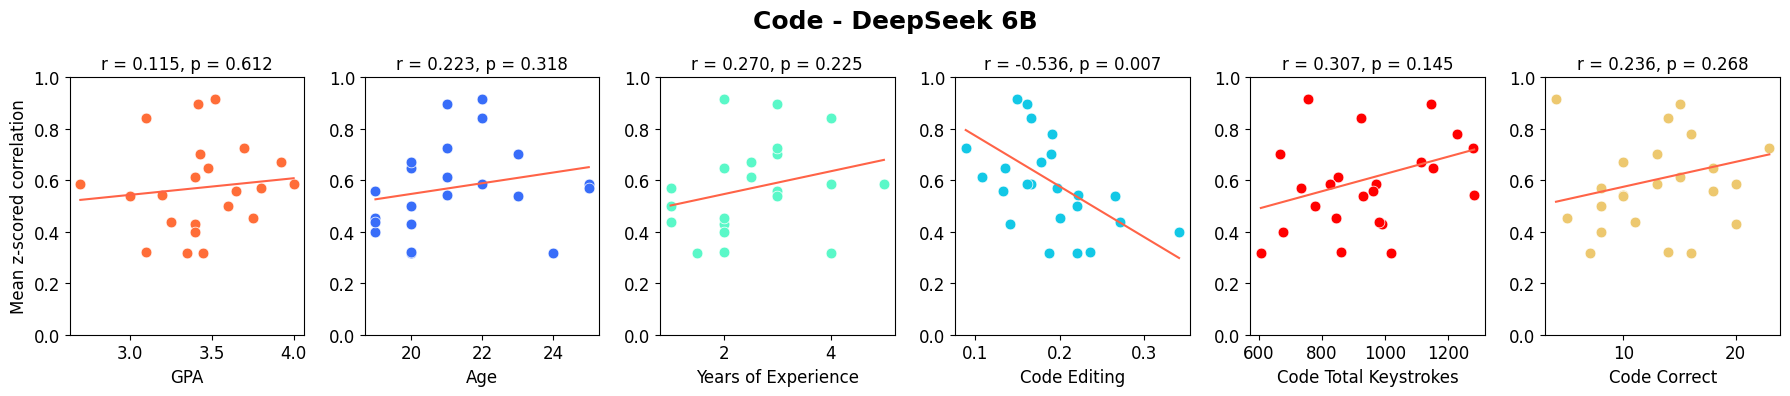

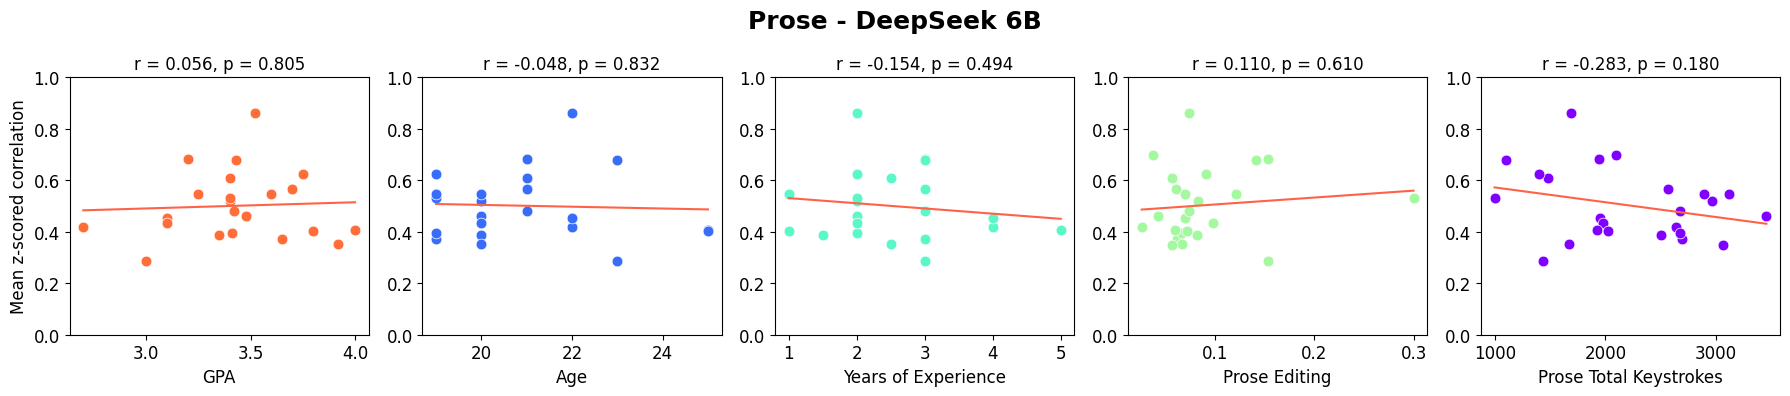

In [9]:
for m in best_models:
    parts = m.split('-')
    task, model, delays, look_ahead = parts[0], parts[1], parts[2], parts[3]

    # Filter variables based on task
    if task == 'code':
        exclude = {'Prose Editing', 'Prose Total Keystrokes'}
    else:
        exclude = {'Code Editing', 'Code Total Keystrokes', 'Code Correct'}
    filtered_vars = {k: v for k, v in variables.items() if k not in exclude}

    performance = participant_means[m]  # {pid: mean_val}
    pids = list(participant_means[m].keys())
    pids = [int(p) for p in pids]
    common_ids = [pid for pid in pids if pid in demo_data.index]
    brain_vals = np.array([performance[str(pid)] for pid in common_ids])

    fig, axes = plt.subplots(1, len(filtered_vars), figsize=(18, 4))
    fig.suptitle(model_labels[m], fontsize=18, fontweight='bold')

    var_keys = list(variables.keys())
    for ax, (var_label, col) in zip(axes, filtered_vars.items()):
        color = palette[var_keys.index(var_label)] 
        demo_vals = demo_data.loc[common_ids, col].values.astype(float)
        # print(color)

        mask = ~np.isnan(demo_vals)
        x, y = demo_vals[mask], brain_vals[mask]

        r, p = stats.pearsonr(x, y)

        ax.scatter(x, y, color=color, edgecolors='white', linewidths=0.5, s=60)
        m_fit, b_fit = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m_fit * x_line + b_fit, color='tomato', linewidth=1.5)
        ax.set_ylim([0.0, 1.0])
        ax.set_xlabel(var_label, fontsize=12)
        ax.tick_params(axis='both', labelsize=12)
        ax.set_ylabel('Mean z-scored correlation' if ax == axes[0] else '', fontsize=12)
        ax.set_title(f"r = {r:.3f}, p = {p:.3f}", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"/tank/home/zachkaras/fmri_model_data/plots/corr_{task}.png", dpi=200, bbox_inches='tight')
    plt.show()